In [83]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [20]:
# trasform the csv file to a dataframe 
df = pd.read_csv('C:/Users/ISHMO_CT/Desktop/projects/Loan_ML/Data/loan_data [Task 1-3] - loan_data.csv')

In [21]:
# print the first five rows of the data
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [22]:
# drop the Loan Id columns because it is unque throught so it won't help us in our model
# or we can make it an index 
df = df.set_index('Loan_ID')
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [23]:
# split the data into target and features 
target = 'Loan_Status'
y = df[target]
X = df.drop(columns=target)

In [24]:
# To esnure we have splitted our data the right way I print the shapes of target and features 
print(y.shape)
print(X.shape)

(614,)
(614, 11)


TASK 1


1a. Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [25]:
# split the data into test and train set 
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# print out the shapes to make sure I have splitted the datset right 
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(491, 11)
(491,)
(123, 11)
(123,)


In [27]:
# I will first clean the data 
# I diplayed the datatypes for the columns 
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [28]:
# According to the dependets the column in the df should be numeric (number int)
# however when we display it it says it is an object
# Lets display the unique or value counts to find iut what is causing it
df['Dependents'].value_counts()

# According to the diction this is number of depedants and this is an ordinal column so 
# The + is on 3 turns the column in to datatype of objet I will not change because it change the meaning
# # 3+ means the the loaner has either 3 or morethan so I will treat this as an ordinal columns and transform it

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

1b. Create a model pipeline (for feature transformations)

In [30]:
# Odentiify different datatypes in the dataframe and create trsnfrmation Pipeline 
# identify ordinal columns in features
ordinal_features = ['Dependents']
# define a transformation Pipeline for the ordinal features 
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Identify categorical columns
nominal_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', ]
#define transformation pipeline for the categorical features
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="MISSING")),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
# Identify numerical columns 
numerical_features = ['Credit_History', 'Loan_Amount_Term', 'LoanAmount', 'CoapplicantIncome', 'ApplicantIncome']
# Define the tranformation pipeline for the numerical features
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


In [32]:
# I created a columns tranfromer to inlcude all my pipelines tuples 
column_transformer = ColumnTransformer(transformers=[
    ('ordinal', ordinal_pipeline, ordinal_features),
    ('nominal', nominal_pipeline, nominal_features),
    ('numeric', numerical_pipeline, numerical_features)
])

In [38]:
# I create the final model pipeline to including instatiating the model
dt_default_pipeline = Pipeline(steps=[
    ('processors', column_transformer),
    ('dt_classifier', DecisionTreeClassifier())
])

dt_default_pipeline.fit(X_train, y_train)

Pipeline(steps=[('processors',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('dt_classifier', DecisionTreeClassifier())])

In [42]:
# Lets have look at our transformed data before it was trained 
X_train_transformed = dt_default_pipeline.named_steps['processors'].transform(X_train)
# Convert the transformed features to a DataFrame with appropriate column names
X_train_transformed_dt = pd.DataFrame(X_train_transformed, columns=dt_default_pipeline.named_steps['processors'].get_feature_names_out())
# View the transformed data
X_train_transformed_dt.head()

,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.199099e-16,0.295122,1.349134,0.180667,0.083915
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.205624,0.385430,-0.429338
2,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,0.710987,0.005831,0.126095
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.240432,0.464185,-0.576970
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-2.434254e+00,0.295122,-0.588512,-0.528127,-0.225522


In [35]:
# lets print the shape to confirm we are using tht right train set 
X_train_transformed_dt.shape

(491, 20)

1. Start by building and evaluating a default decision tree model using appropriate metrics and a confusion matrix.

In [47]:
# Lets me evaluate the model 
# We start by testing the model 
#I realized we don't need to column transform the X_test set because the pipline with the model will do it for us


In [48]:
# Then now I can test model 
# I will test the default model using the test set 
# default_test_pred =  dt_default_pipeline.predict(X_test_transformed)
default_test_pred =  dt_default_pipeline.predict(X_test)
default_test_pred

array(['Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y',
       'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'Y', 'N'], dtype=object)

In [49]:
# Lets me now evaluate the default model using classification report  and confusion matrix
# Let me start with classification report 
# Here I am comparing the actual test values with what the model predicted 
print(classification_report(y_test, default_test_pred))

              precision    recall  f1-score   support

           N       0.51      0.49      0.50        43
           Y       0.73      0.75      0.74        80

    accuracy                           0.66       123
   macro avg       0.62      0.62      0.62       123
weighted avg       0.65      0.66      0.66       123



In [50]:
# Then I print out the confusion_matrix still in comparison of the actual test sest target values and what the model predicted
confusion_matrix(y_test, default_test_pred)

array([[21, 22],
       [20, 60]])

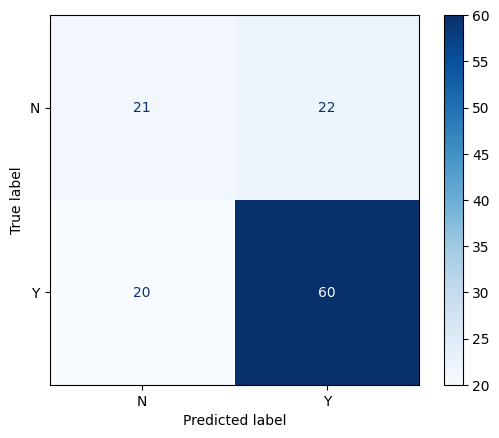

In [51]:
# let me now display it the cinfusion matrix in image form
ConfusionMatrixDisplay.from_predictions(y_test, default_test_pred, cmap="Blues")

Task1. 2. Then, use GridSearchCV to tune the model. Be sure to change the default scoring to "recall_macro" when you instantiate the GridSearch.  (Be sure to explain the GridSearchCV technique)

Grid Search Cross-Validation (GridSearchCV) is a hyperparameter tuning technique in machine learning that helps find the best combination of hyperparameters for a model by exhaustively searching through a specified parameter grid. It evaluates a model's performance for each combination of parameters, typically using cross-validation to get an unbiased estimate of performance.


In [57]:
# Before I instatiate the Grid search 
# I don't need to instatiate the model again since I already have we shall use the original model
# I need to define a dictionary of parameters (hyperparameters) to be used in the GridSearchCV


# parameters for tuning 
param_grid = {
    'dt_classifier__criterion': ['gini', 'entropy'],
    'dt_classifier__max_depth': [3, 5, 10, None],
    'dt_classifier__min_samples_split': [2, 5, 10],
    'dt_classifier__min_samples_leaf': [1, 2, 4]
}

In [58]:
#lets instatiate the grid search cv to tune model
# The Grid search cv has different attributes
# DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=2)
grid_search = GridSearchCV(
    estimator=dt_default_pipeline,      # atrribute for the model tobe used
    param_grid=param_grid,   #attribute for thr parameters to tune the model with different values
    scoring="recall_macro",  # scoring metrics (Actually good for imbalanced malticlass problems)
    cv=5,                    # cross validation (we are using 5 here)
    verbose=1,               # to diplay the progress
    n_jobs=-1,               # to utelize all my cpu cores 
    return_train_score=True  # store training scores in cv results
)

In [59]:
# Lets fit the the data with the model 
# I am going to use my x training data set transformed data 
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('processors',
                                        ColumnTransformer(transformers=[('ordinal',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder())]),
                                                                         ['Dependents']),
                                                                        ('nominal',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='MISSING',
                                                                                                        strategy='constant')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ig...
                                                                          'LoanAmount',
                                                                          'CoapplicantIncome',
                                                                          'ApplicantIncome'])])),
                                       ('dt_classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dt_classifier__criterion': ['gini', 'entropy'],
                         'dt_classifier__max_depth': [3, 5, 10, None],
                         'dt_classifier__min_samples_leaf': [1, 2, 4],
                         'dt_classifier__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='recall_macro', verbose=1)

In [60]:
# I found out best model from grid search
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('processors',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('dt_classifier',
                 DecisionTreeClassifier(max_depth=3, min_samples_leaf=2))])

Task 1, 3. Visualize the trees from both the default and the tuned model versions.

In [ ]:
# before I visualise I need to find the featire names for the x_train that was transformed
# rememeber that in our pipeline we used column tranformer to encode feature so more columns were created
# start by grabbing the column transformer 
transformed_columns = []
ct = dt_default_pipeline.named_steps['processors']

# use a loop to loop through our pipeline step for trnsforming data 
for name, transformer, columns in ct.transformers_:
    if name == 'remainder':
        continue  
    if hasattr(transformer, 'get_feature_names_out'):
        names = transformer.get_feature_names_out(columns)
    else:
        names = columns
    transformed_columns.extend(names)
transformed_columns

['Dependents',
 'Gender_Female',
 'Gender_MISSING',
 'Gender_Male',
 'Married_MISSING',
 'Married_No',
 'Married_Yes',
 'Education_Graduate',
 'Education_Not Graduate',
 'Self_Employed_MISSING',
 'Self_Employed_No',
 'Self_Employed_Yes',
 'Property_Area_Rural',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'Credit_History',
 'Loan_Amount_Term',
 'LoanAmount',
 'CoapplicantIncome',
 'ApplicantIncome']

c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.44097699175824173, 0.9705882352941176, 'Credit_History <= -1.217\ngini = 0.423\nsamples = 491\nvalue = [149, 342]\nclass = Y'),
 Text(0.08241758241758242, 0.9117647058823529, 'CoapplicantIncome <= 2.028\ngini = 0.157\nsamples = 70\nvalue = [64, 6]\nclass = N'),
 Text(0.26169728708791207, 0.9411764705882353, 'True  '),
 Text(0.054945054945054944, 0.8529411764705882, 'ApplicantIncome <= -0.2\ngini = 0.136\nsamples = 68\nvalue = [63, 5]\nclass = N'),
 Text(0.03296703296703297, 0.7941176470588235, 'Loan_Amount_Term <= -1.501\ngini = 0.045\nsamples = 43\nvalue = [42, 1]\nclass = N'),
 Text(0.02197802197802198, 0.7352941176470589, 'ApplicantIncome <= -0.499\ngini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = N'),
 Text(0.01098901098901099, 0.6764705882352942, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Y'),
 Text(0.03296703296703297, 0.6764705882352942, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = N'),
 Text(0.04395604395604396, 0.7352941176470589, 'gini = 0.0\nsamples = 3

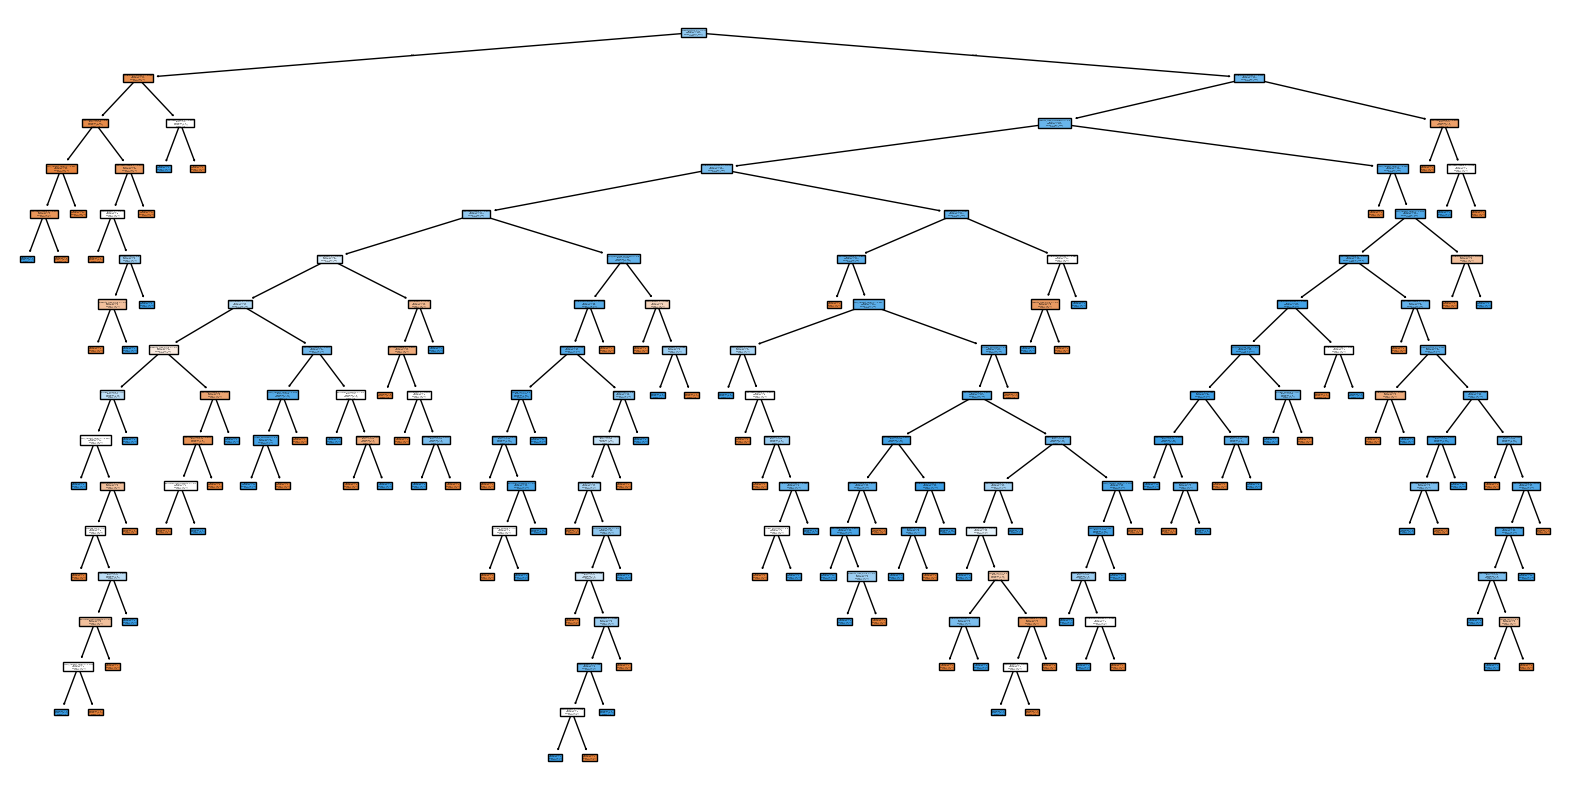

In [ ]:
# here am visualizing the default model 
# I will still need to use model in the Pipeline .named_steps["name"] comes in handy 
plt.figure(figsize=(20,10))
tree.plot_tree(dt_default_pipeline.named_steps['dt_classifier'], feature_names=transformed_columns, class_names=y_train, filled=True)

c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.4583333333333333, 0.875, 'Credit_History <= -1.217\ngini = 0.423\nsamples = 491\nvalue = [149, 342]\nclass = Y'),
 Text(0.25, 0.625, 'CoapplicantIncome <= 2.028\ngini = 0.157\nsamples = 70\nvalue = [64, 6]\nclass = N'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'ApplicantIncome <= -0.2\ngini = 0.136\nsamples = 68\nvalue = [63, 5]\nclass = N'),
 Text(0.08333333333333333, 0.125, 'gini = 0.045\nsamples = 43\nvalue = [42, 1]\nclass = N'),
 Text(0.25, 0.125, 'gini = 0.269\nsamples = 25\nvalue = [21, 4]\nclass = N'),
 Text(0.3333333333333333, 0.375, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = N'),
 Text(0.6666666666666666, 0.625, 'CoapplicantIncome <= 2.512\ngini = 0.322\nsamples = 421\nvalue = [85, 336]\nclass = Y'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'Property_Area_Semiurban <= 0.5\ngini = 0.314\nsamples = 416\nvalue = [81, 335]\nclass = Y'),
 Text(0.4166666666666667, 0.125, 'gini = 0.369\nsamples = 250\nvalue = [61, 189]\ncl

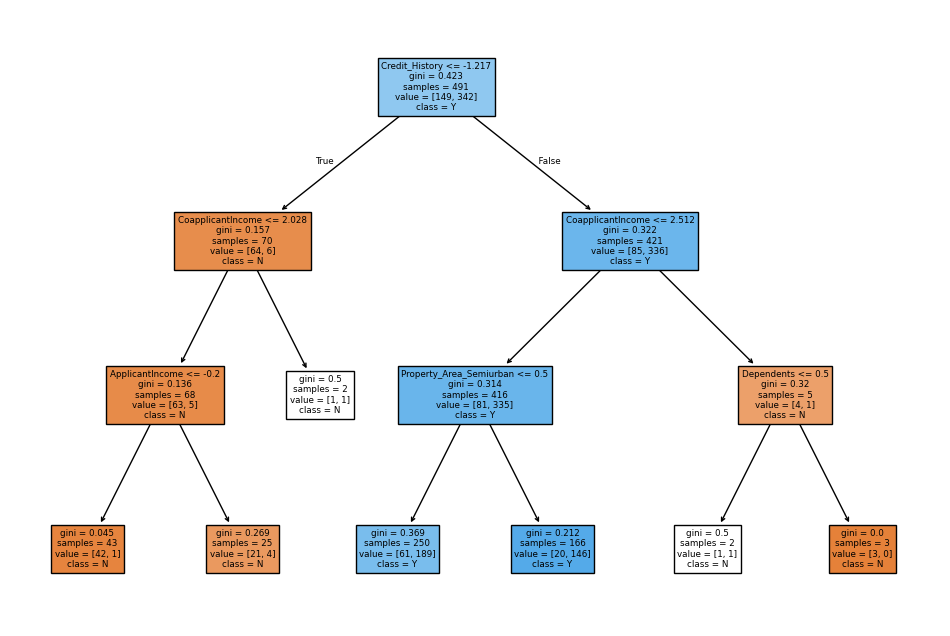

In [76]:
# Here I am visualizing the best model from the grid search view 
plt.figure(figsize=(12,8))
tree.plot_tree(best_model.named_steps['dt_classifier'], feature_names=transformed_columns, class_names=y_train,  filled=True)

Task 1. 4.Make sure you have evaluated both the default and the tuned versions using appropriate metrics and a confusion matrix.

In [77]:
# I have already evaluated the default model model 
# here I am going to evaluate the tuned version (best model)
# I will start by predicting using the best model 
best_model_pred = best_model.predict(X_test)
best_model_pred

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y'], dtype=object)

In [78]:
# Then now evaluate the version model  using the actual target values of test set and the values predicted by the tuned model
# using confusion report
print(classification_report(y_test, best_model_pred))

              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [79]:
# Let me display the confusion matrix 
confusion_matrix(y_test, best_model_pred)

array([[18, 25],
       [ 1, 79]])

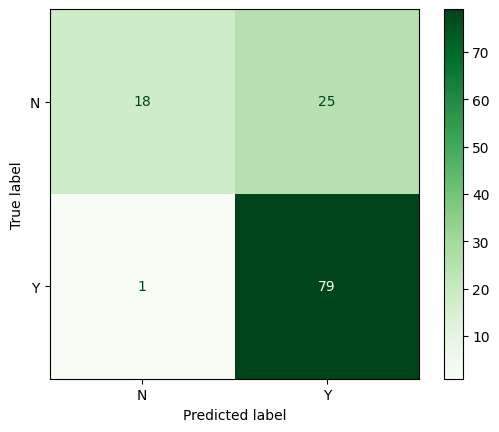

In [80]:
# let me display the confusion matrix 
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred, cmap="Greens")

Task1. 5.Which combination of hyperparameters led to the best-tuned model?

In [81]:
# to find the best parameters in the grid search that made the best tuned model we will use  .best_params_ 
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'dt_classifier__criterion': 'gini', 'dt_classifier__max_depth': 3, 'dt_classifier__min_samples_leaf': 2, 'dt_classifier__min_samples_split': 2}


In [82]:
# best_param = {
#     'criterion': 'entropy', 
#     'max_depth': 10, 
#     'max_leaf_nodes': 10, 
#     'min_samples_leaf': 2, 
#     'min_samples_split': 5
# }

Task 2- SVM Algorithm
From first principles, explain the SVM algorithm, highlight the pros and cons of this algorithm.

This is how I understood SVM. 
SVM a supervised machine learning algorithm used for classification (and sometimes regression).
It finds the best boundary (hyperplane) that separates data points of different classes.


### In lay man terms
Lets say I have two types of fruits carrots and apples
I will use the size and color to differeciate them.
I will arrange them in way acording sizes ofcourse carrots are abit long so they will find them selves on one side and the apples on the other. Then I draw a line (hyperplane) between them. 


The same way SVM finds the best possible boundary (called a hyperplane) that splits the apples from the carrots, with the most space (margin) on both sides.


I used a line to separate them however in this case this more than a line that is why there is word hyperplane in brackets.
When the line is drawn a certain distance is measured to stay as far away from both groups (carrots and apples) as possible.
That distance is defined support vectors. The suppot vectors define how far away the line should go 


Here is the link to my drawing to illustrate it 
https://drive.google.com/file/d/1tAn4NCccYUqw7XP5Xsxqe3m2PyywGwYn/view?usp=sharing


### Mathematically here is the explanation

Assume we have:

- A dataset with two features: (color) `x₁` and size `x₂`
- Two classes labeled as: (carrot) `y = +1` and (apples)`y = -1`

wᵀx + b = 0
Where:

- `w` is the **weight vector**
- `b` is the **bias** (a constant that shifts the hyperplane)
- `x` is the **input vector** (a data point)

This equation represents the decision boundary that separates the two classes.

##  Pros of Support Vector Machines (SVM)

| Feature                          | Explanation                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| **Effective in high-dimensional spaces** | Works well when number of features greater than number of samples (e.g., text classification, gene expression). |
| **Robust to overfitting**       | Maximizing the margin helps generalize well with proper regularization.     |
| **Performs well with clear margin** | Excellent performance when the data is clearly separable.                |
| **Flexible with Kernels**       | Supports linear, polynomial, RBF, and custom kernels to handle non-linearity. |
| **Sparse support vectors**      | Only support vectors affect the decision function, making it memory efficient in some cases. |

##  Cons of Support Vector Machines (SVM)

| Feature                          | Explanation                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| **Computationally expensive**   | Slow training on large datasets (complexity up to O(n³)).                    |
| **Hard to tune**                | Choosing the right kernel, C, and gamma can be tricky and needs cross-validation. |
| **Sensitive to outliers**       | Outliers can distort the margin and affect model performance.               |
| **Poor performance with overlapping classes** | Struggles when classes are not well separated.                         |
| **Not easily interpretable**    | Difficult to explain the model, especially with non-linear kernels.         |




Task 2a. Build an SVM classifier
Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [14]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# Since I had already created my Pipeline for feature transformation I will use that
# This time I am using SVM model in my Pipeline 
svm_pipeline = Pipeline([
    ('preprocessor', column_transformer),
    ('svm_classifier', SVC())
])

In [ ]:
# Now I trained the model using train set 
# The Pipeline will handle the transformation and model to be used
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('svm_classifier', SVC())])

In [89]:
# before we evaluate we need to test the model using the test set and get predictions for the test set
# I don't need to worry about transforming the test set since the pipeline has both the model and the column tranformer 
svm_predit = svm_pipeline.predict(X_test)
svm_predit


array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y'], dtype=object)

In [90]:
# Now I will evaluate the using the the actual target values of the test set and the predictions from the model 
print(classification_report(y_test, svm_predit))

              precision    recall  f1-score   support

           N       0.90      0.42      0.57        43
           Y       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [91]:
confusion_matrix(y_test, svm_predit)

array([[18, 25],
       [ 2, 78]])

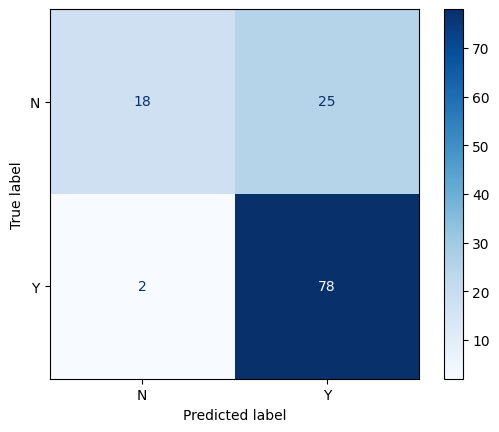

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_predit, cmap="Blues")

Describe your results.

Y represents Yes (Qualifies for loan)

N represents No (not qualified for loan)
| Metric                  | Value | Explanation                                      |
|-------------------------|-------|--------------------------------------------------|
| **True Negatives (TN)** | 18    | Correctly predicted N                            |
| **False Positives (FP)**| 25    | Predicted Y, but was actually N                  |
| **False Negatives (FN)**| 2     | Predicted N, but was actually Y                  |
| **True Positives (TP)** | 78    | Correctly predicted Y                            |
| **Precision (N)**       | 0.90  | Out of all predicted N, 90% were actually N      |
| **Recall (N)**          | 0.42  | Out of all actual N, only 42% were predicted     |
|                         |       |               |
| **Precision (Y)**       | 0.76  | 76% of predicted Y were correct                  |
| **Recall (Y)**          | 0.97  | Model caught almost all actual Y cases           |
|                         |       | → Only missed 2 out of 80 actual Y instances     |



The SVM model is very good at detecting Y (positive class). It is actually better than the tuned decision tree model

But it struggles abit with class N — it misclassifies many N cases as Y.

This could be due to Class imbalance.
when you look at the data target value count. there is an imbalance.


Task 3 -  Random Forest
From first principles, explain the Random Forest, highlight the pros and cons of this algorithm.
